# Rede neural MLP no Iris

**Autor:** Prof. Dr. Sergio Antônio Andrade de Freitas  
**Material da disciplina:** FGA0083 — Aprendizado de Máquina, UnB

## Objetivo e dados

Comparar MLP padronizada com uma linha de base simples.

**Pergunta-guia:** O ganho sobre a linha de base compensa maior complexidade?

Execute as células na ordem e interprete os resultados antes de fazer o exercício.

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Carrega o Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# 2. Divide em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Cria pipeline com escalonamento + MLP
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(20,10),    # duas camadas ocultas: 20 e 10 neurônios
        activation='relu',
        solver='adam',
        learning_rate_init=0.01,
        max_iter=1000,
        tol=1e-4,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=1,
        verbose=False
    ))
])

# 4. Treina o modelo
with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
    pipeline.fit(X_train, y_train)
assert np.isfinite(pipeline[-1].loss_curve_).all(), 'Perda não finita na MLP'

# 5. Faz previsões
with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
    y_pred = pipeline.predict(X_test)
assert np.isin(y_pred, np.unique(y_train)).all(), 'Classe prevista desconhecida'

# 6. Avalia performance
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=iris.target_names)

print(f"Acurácia: {accuracy:.2f}\n")
print("Relatório de classificação:\n", report)

Acurácia: 0.96

Relatório de classificação:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.93      0.93      0.93        15
   virginica       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



## Investigação complementar

Compare a nova medida com a figura ou o resultado anterior. Explique qualquer diferença observada.

Acurácia da regressão logística no mesmo teste: 0.91
Épocas da MLP: 67; melhor validação interna: 1.00


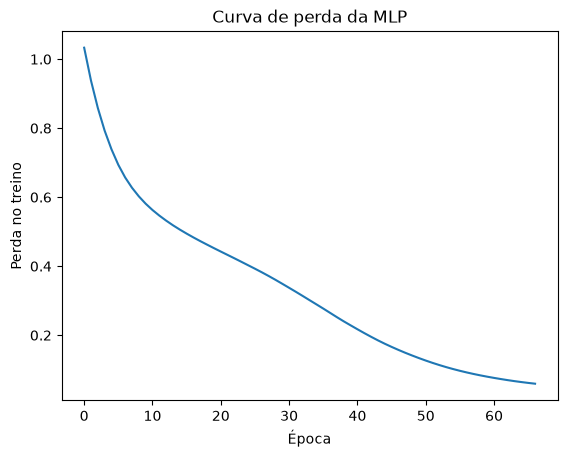

In [2]:
from sklearn.linear_model import LogisticRegression
base = Pipeline([('scaler', StandardScaler()), ('modelo', LogisticRegression(max_iter=1000))])
base.fit(X_train, y_train)
print(f'Acurácia da regressão logística no mesmo teste: {accuracy_score(y_test, base.predict(X_test)):.2f}')
print(f'Épocas da MLP: {pipeline[-1].n_iter_}; melhor validação interna: {pipeline[-1].best_validation_score_:.2f}')
import matplotlib.pyplot as plt
plt.plot(pipeline[-1].loss_curve_)
plt.xlabel('Época'); plt.ylabel('Perda no treino'); plt.title('Curva de perda da MLP'); plt.show()

## Interpretação e limites

`early_stopping` retira parte do treino para validação; o teste continua reservado.

## Exercício

Varie camadas e semente, registre curva de perda e estabilidade da acurácia.

Registre a hipótese, a mudança realizada, a métrica ou figura observada e uma conclusão que os dados de fato sustentem.